# 1 - Simple Pitch Analysis of Jazz Corpus

## Imports

In [4]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

In [5]:
%reload_ext autoreload
import pandas as pd
from fractions import Fraction
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm
import music21 as m21

In [6]:
%reload_ext autoreload
import sys
sys.path.append('/Users/Jessica/Documents/ERIP2025/Jessica-ERIP2025/')

from Importables import General as g
from Importables import pitchanalysis_utils as pa

In [54]:
metadata = g.load_metadata()

In [56]:
notes = g.load_notes(metadata, keys=True)

In [57]:
notes_C = pa.transpose_to_C(notes)

In [58]:
notes_C = notes_C[notes_C['transposed note'].notna()]

In [59]:
bins = np.arange(1930, 2030, 10) 
bin_labels = [f"{start}-{start+10}" for start in bins[:-1]]

subset_year = notes_C[notes_C['recording_year'].notna()].copy()
subset_year['year_bin'] = pd.cut(subset_year['recording_year'], bins=bins, labels=bin_labels, right=False)

## Example: Subset

In [16]:
subset = metadata[(metadata['workTitle'] == 'Four') | (metadata['workTitle'] == 'Blues By Five')]
subset = subset[subset['artists'].isin(['John Coltrane', 'Miles Davis'])]
subset = g.load_notes(subset)
identifier = ['artist', 'workTitle']
subset = subset.groupby(identifier, as_index=False).agg(list)
subset

,artist,workTitle,mc,mn,mc_onset,mn_onset,timesig,staff,voice,duration,...,volta,chord_id,pc,note,time,fnames,rel_paths,recording_year,label,ILS
0,John Coltrane,Blues By Five,"[2, 2, 2, 3, 3, 3, 3, 3, 3, 4, 4, 4, 4, 4, 6, ...","[2, 2, 2, 3, 3, 3, 3, 3, 3, 4, 4, 4, 4, 4, 6, ...","[0.5, 0.625, 0.875, 0.0, 0.125, 0.375, 0.5, 0....","[1/2, 5/8, 7/8, 0, 1/8, 3/8, 1/2, 3/4, 7/8, 0,...","[4/4, 4/4, 4/4, 4/4, 4/4, 4/4, 4/4, 4/4, 4/4, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[0.125, 0.25, 0.125, 0.125, 0.25, 0.125, 0.25,...",...,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[8, 10, 0, 0, 3, 5, 5, 8, 10, 10, 5, 8, 7, 5, ...","[Ab, Bb, C, C, Eb, F, F, Ab, Bb, Bb, F, Ab, G,...","[2.5, 2.625, 2.875, 3.0, 3.125, 3.375, 3.5, 3....","[Blues By Five - John Coltrane (Concert Key), ...","[by_Carles_Margarit, by_Carles_Margarit, by_Ca...","[1956.0, 1956.0, 1956.0, 1956.0, 1956.0, 1956....","[E-7, E-7, E-7, B-7, B-7, B-7, B-7, B-7, B-7, ...","[[E-, G, B-, D-], [E-, G, B-, D-], [E-, G, B-,..."
1,John Coltrane,Four,"[9, 9, 9, 10, 10, 10, 10, 10, 10, 11, 11, 11, ...","[9, 9, 9, 10, 10, 10, 10, 10, 10, 11, 11, 11, ...","[0.625, 0.75, 0.875, 0.125, 0.25, 0.375, 0.625...","[5/8, 3/4, 7/8, 1/8, 1/4, 3/8, 5/8, 3/4, 7/8, ...","[4/4, 4/4, 4/4, 4/4, 4/4, 4/4, 4/4, 4/4, 4/4, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[0.125, 0.125, 0.125, 0.125, 0.125, 0.125, 0.1...",...,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[10, 0, 2, 10, 0, 2, 10, 0, 2, 5, 3, 2, 10, 0,...","[Bb, C, D, Bb, C, D, Bb, C, D, F, Eb, D, Bb, C...","[9.625, 9.75, 9.875, 10.125, 10.25, 10.375, 10...","[Four - John Coltrane (Concert Key), Four - Jo...","[by_Carles_Margarit, by_Carles_Margarit, by_Ca...","[1956.0, 1956.0, 1956.0, 1956.0, 1956.0, 1956....","[E-M7, E-M7, E-M7, E-M7, E-M7, E-M7, E-M7, E-M...","[[E-, G, B-, D], [E-, G, B-, D], [E-, G, B-, D..."
2,Miles Davis,Blues By Five,"[1, 1, 1, 2, 2, 2, 2, 3, 3, 5, 5, 5, 5, 5, 5, ...","[1, 1, 1, 2, 2, 2, 2, 3, 3, 5, 5, 5, 5, 5, 5, ...","[0.0, 0.25, 0.5, 0.375, 0.5, 0.625, 0.75, 0.0,...","[0, 1/4, 1/2, 3/8, 1/2, 5/8, 3/4, 0, 1/4, 0, 1...","[4/4, 4/4, 4/4, 4/4, 4/4, 4/4, 4/4, 4/4, 4/4, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[0.25, 0.25, 0.25, 0.125, 0.125, 0.125, 0.25, ...",...,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[10, 10, 10, 1, 2, 1, 2, 10, 10, 7, 10, 0, 10,...","[Bb, Bb, Bb, C#, D, C#, D, Bb, Bb, G, Bb, C, B...","[1.0, 1.25, 1.5, 2.375, 2.5, 2.625, 2.75, 3.0,...","[Blues By Five - Miles Davis (Concert Key), Bl...","[by_Carles_Margarit, by_Carles_Margarit, by_Ca...","[1956.0, 1956.0, 1956.0, 1956.0, 1956.0, 1956....","[B-7, B-7, B-7, E-7, E-7, E-7, E-7, B-7, B-7, ...","[[B-, D, F, A-], [B-, D, F, A-], [B-, D, F, A-..."
3,Miles Davis,Four,"[9, 9, 9, 10, 10, 10, 10, 10, 10, 11, 11, 11, ...","[9, 9, 9, 10, 10, 10, 10, 10, 10, 11, 11, 11, ...","[0.625, 0.75, 0.875, 0.125, 0.25, 0.375, 0.625...","[5/8, 3/4, 7/8, 1/8, 1/4, 3/8, 5/8, 3/4, 7/8, ...","[4/4, 4/4, 4/4, 4/4, 4/4, 4/4, 4/4, 4/4, 4/4, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[0.125, 0.125, 0.125, 0.125, 0.125, 0.125, 0.1...",...,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[0, 2, 4, 0, 2, 4, 0, 2, 4, 7, 5, 4, 0, 2, 3, ...","[C, D, E, C, D, E, C, D, E, G, F, E, C, D, Eb,...","[9.625, 9.75, 9.875, 10.125, 10.25, 10.375, 10...","[Four - Miles Davis (Concert Key), Four - Mile...","[by_Carles_Margarit, by_Carles_Margarit, by_Ca...","[1956.0, 1956.0, 1956.0, 1956.0, 1956.0, 1956....","[FM7, FM7, FM7, FM7, FM7, FM7, FM7, FM7, FM7, ...","[[F, A, C, E], [F, A, C, E], [F, A, C, E], [F,..

In [1176]:

data = pa.create_data(subset, identifier)
pa.plot_pitch_distribution(data, identifier)

{('John Coltrane',
  'Blues By Five'): note        [Ab, Bb, C, C, Eb, F, F, Ab, Bb, Bb, F, Ab, G,...
 tpc         [-4, -2, 0, 0, -3, -1, -1, -4, -2, -2, -1, -4,...
 duration    [0.125, 0.25, 0.125, 0.125, 0.25, 0.125, 0.25,...
 Name: 0, dtype: object,
 ('John Coltrane',
  'Four'): note        [Bb, C, D, Bb, C, D, Bb, C, D, F, Eb, D, Bb, C...
 tpc         [-2, 0, 2, -2, 0, 2, -2, 0, 2, -1, -3, 2, -2, ...
 duration    [0.125, 0.125, 0.125, 0.125, 0.125, 0.125, 0.1...
 Name: 1, dtype: object,
 ('Miles Davis',
  'Blues By Five'): note        [Bb, Bb, Bb, C#, D, C#, D, Bb, Bb, G, Bb, C, B...
 tpc         [-2, -2, -2, 7, 2, 7, 2, -2, -2, 1, -2, 0, -2,...
 duration    [0.25, 0.25, 0.25, 0.125, 0.125, 0.125, 0.25, ...
 Name: 2, dtype: object,
 ('Miles Davis',
  'Four'): note        [C, D, E, C, D, E, C, D, E, G, F, E, C, D, Eb,...
 tpc         [0, 2, 4, 0, 2, 4, 0, 2, 4, 1, -1, 4, 0, 2, -3...
 duration    [0.125, 0.125, 0.125, 0.125, 0.125, 0.125, 0.1...
 Name: 3, dtype: object}

## By Artist

In [46]:
grouped_artists = metadata['artists'].value_counts()
subset_artists = grouped_artists.iloc[0:15].index
subset = metadata[metadata['artists'].isin(subset_artists)]
subset_artists

Index(['Frank Zappa', 'Bill Evans', 'Yohan Kim', 'Dexter Gordon',
       'Miles Davis', 'Chet Baker', 'Bob Mintzer', 'Paul Desmond',
       'Sonny Stitt', 'Terrence Shider', 'John Coltrane', 'Stan Getz',
       'Keith Jarrett', 'Michael Brecker', 'Mulgrew Miller'],
      dtype='object')

In [48]:
subset = g.load_notes(subset)
identifier = ['artist']
subset = subset.groupby(identifier, as_index=False).agg(list)
data = pa.create_data(subset, identifier)
#pa.plot_pitch_distribution(data, identifier, fig_name='0618_jazz_artist_pitch')

In [54]:
keys = list(data.keys())

all_tpc_data = []

for i, key in enumerate(keys):
    # Format title from key (tuple or string)
    if isinstance(key, tuple):
        label = " – ".join(str(k) for k in key)
    else:
        label = str(key)

    # Get the pitch profile data
    pitch_data = data[key]
    tpc = pd.DataFrame({
        'note': pitch_data['note'],
        'tpc': pitch_data['tpc'],
        'duration': pitch_data['duration']
    })

    all_tpc_data.append(tpc[['note', 'tpc']])  # Only need note and tpc for this task

# Concatenate all DataFrames together
combined_tpc_data = pd.concat(all_tpc_data, ignore_index=True)

# Drop duplicate note-TPC pairs
unique_note_tpc_df = combined_tpc_data.drop_duplicates().reset_index(drop=True)

baseline_df = unique_note_tpc_df.sort_values(by='tpc')

/var/folders/dw/ccr2_55x757_kgq1rt_lyy6c0000gn/T/ipykernel_9472/1815477327.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = plt.cm.get_cmap('tab20', len(keys))  # Distinct colors


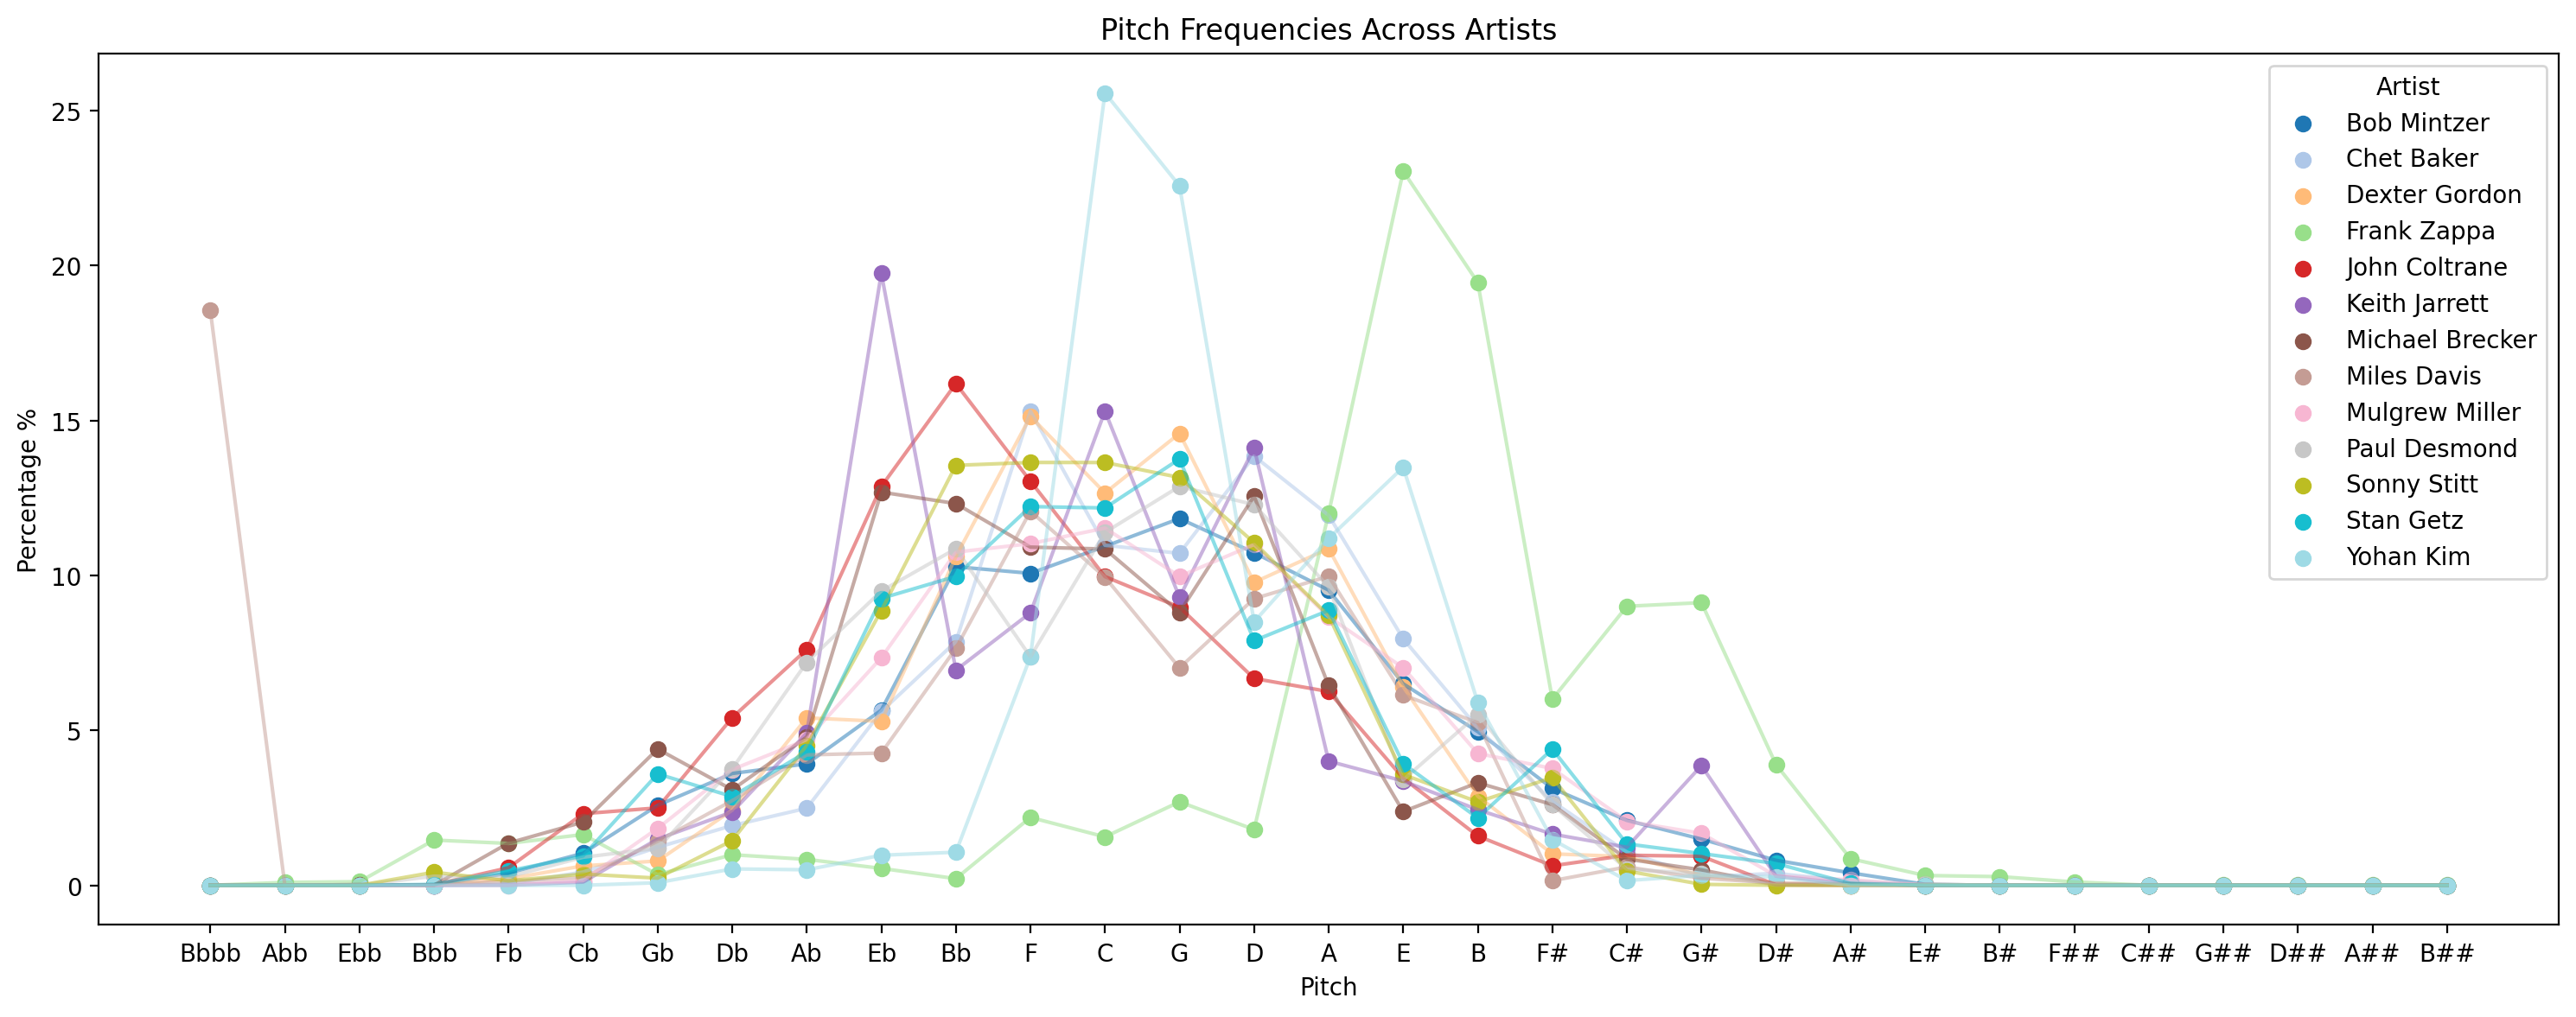

In [56]:
fig, ax = plt.subplots(figsize=(15, 6))  # One figure and one axis

colors = plt.cm.get_cmap('tab20', len(keys))  # Distinct colors

for i, key in enumerate(keys):
    # Format title from key (tuple or string)
    if isinstance(key, tuple):
        label = " – ".join(str(k) for k in key)
    else:
        label = str(key)

    # Get the pitch profile data
    pitch_data = data[key]
    tpc = pd.DataFrame({
        'note': pitch_data['note'],
        'tpc': pitch_data['tpc'],
        'duration': pitch_data['duration']
    })

    pitch_counts = tpc.groupby(['note', 'tpc'])['duration'].sum().reset_index(name='weighted_count')
    count = pitch_counts.sort_values('tpc')
    total = count['weighted_count'].sum()
    count['percentage'] = (count['weighted_count'] / total)*100

    merged_df = pd.merge(
        baseline_df[['note']],
        count[['note', 'percentage']],
        on='note',
        how='left'
    )
    
    # Step 3: fill NaNs with 0 where artist didn't have that interval
    merged_df['percentage'] = merged_df['percentage'].fillna(0)

    # Plot line for this artist
    ax.plot(merged_df['note'], merged_df['percentage'], color=colors(i), alpha=0.5)
    ax.scatter(merged_df['note'], merged_df['percentage'], label=label, color=colors(i))
    #print(count)

# Axis labels and title
ax.set_xlabel('Pitch')
ax.set_ylabel('Percentage %')
ax.set_title(f'Pitch Frequencies Across Artists')
ax.legend(title='Artist')

plt.tight_layout()
plt.savefig(f"../Results/0623_ArtistPitchOverlay")
plt.show()

## By Year

In [64]:
identifier = ['year_bin']
subset_year = subset_year.groupby(identifier, as_index=False).agg(list)

In [65]:
data_year = pa.create_data(subset_year, identifier)

In [70]:
keys = list(data_year.keys())

all_tpc_data = []

for i, key in enumerate(keys):
    # Format title from key (tuple or string)
    if isinstance(key, tuple):
        label = " – ".join(str(k) for k in key)
    else:
        label = str(key)

    # Get the pitch profile data
    pitch_data = data_year[key]
    tpc = pd.DataFrame({
        'note': pitch_data['note'],
        'tpc': pitch_data['tpc'],
        'duration': pitch_data['duration'],
        'transposed note': pitch_data['transposed note'],
        'transposed tpc': pitch_data['transposed tpc']
    })

    all_tpc_data.append(tpc[['note', 'tpc', 'transposed note', 'transposed tpc']])  # Only need note and tpc for this task

# Concatenate all DataFrames together
combined_tpc_data = pd.concat(all_tpc_data, ignore_index=True)

# Drop duplicate note-TPC pairs
unique_note_tpc_df = combined_tpc_data.drop_duplicates().reset_index(drop=True)

baseline_df = unique_note_tpc_df.sort_values(by='tpc')
baseline_df_tranposed = unique_note_tpc_df.sort_values(by='transposed tpc')

/var/folders/dw/ccr2_55x757_kgq1rt_lyy6c0000gn/T/ipykernel_45123/2280557775.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = plt.cm.get_cmap('viridis', len(keys))  # Distinct colors


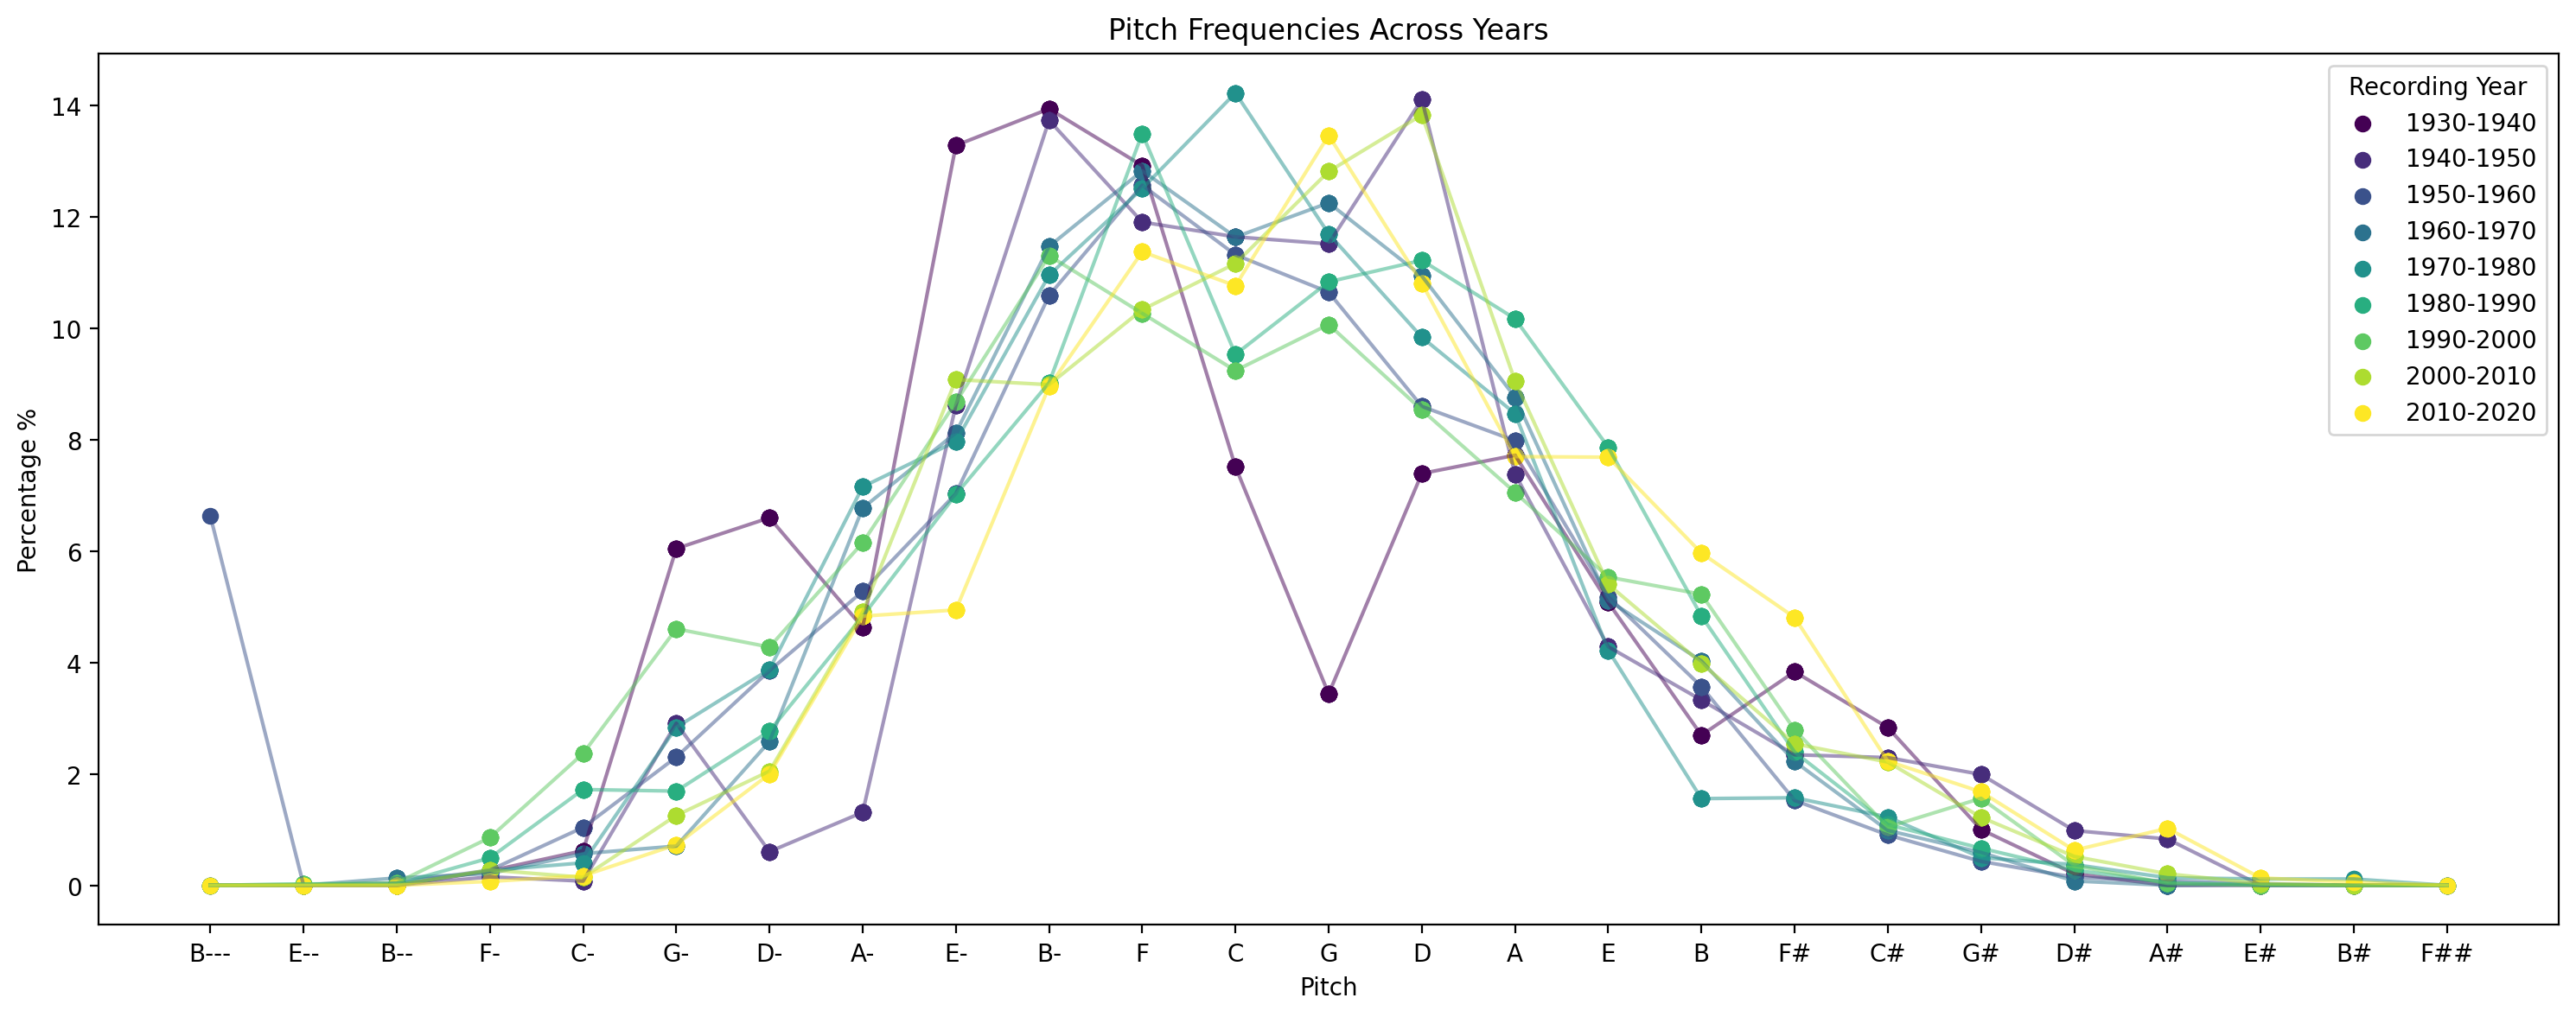

In [72]:
fig, ax = plt.subplots(figsize=(15, 6))  # One figure and one axis

colors = plt.cm.get_cmap('viridis', len(keys))  # Distinct colors

for i, key in enumerate(keys):
    if isinstance(key, tuple):
        label = " – ".join(str(k) for k in key)
    else:
        label = str(key)

    # Get the pitch profile data
    pitch_data = data_year[key]
    tpc = pd.DataFrame({
        'note': pitch_data['note'],
        'tpc': pitch_data['tpc'],
        'duration': pitch_data['duration']
    })

    pitch_counts = tpc.groupby(['note', 'tpc'])['duration'].sum().reset_index(name='weighted_count')
    count = pitch_counts.sort_values('tpc')
    total = count['weighted_count'].sum()
    count['percentage'] = (count['weighted_count'] / total)*100

    merged_df = pd.merge(
        baseline_df[['note']],
        count[['note', 'percentage']],
        on='note',
        how='left'
    )
    
    # Step 3: fill NaNs with 0 where artist didn't have that interval
    merged_df['percentage'] = merged_df['percentage'].fillna(0)

    # Plot line for this artist
    ax.plot(merged_df['note'], merged_df['percentage'], color=colors(i), alpha=0.5)
    ax.scatter(merged_df['note'], merged_df['percentage'], label=label, color=colors(i))

# Axis labels and title
ax.set_xlabel('Pitch')
ax.set_ylabel('Percentage %')
ax.set_title(f'Pitch Frequencies Across Years')
ax.legend(title='Recording Year')

plt.tight_layout()
plt.savefig(f"../Results/0623_YearPitchOverlay")
plt.show()

/var/folders/dw/ccr2_55x757_kgq1rt_lyy6c0000gn/T/ipykernel_45123/3006419953.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = plt.cm.get_cmap('viridis', len(keys))  # Distinct colors


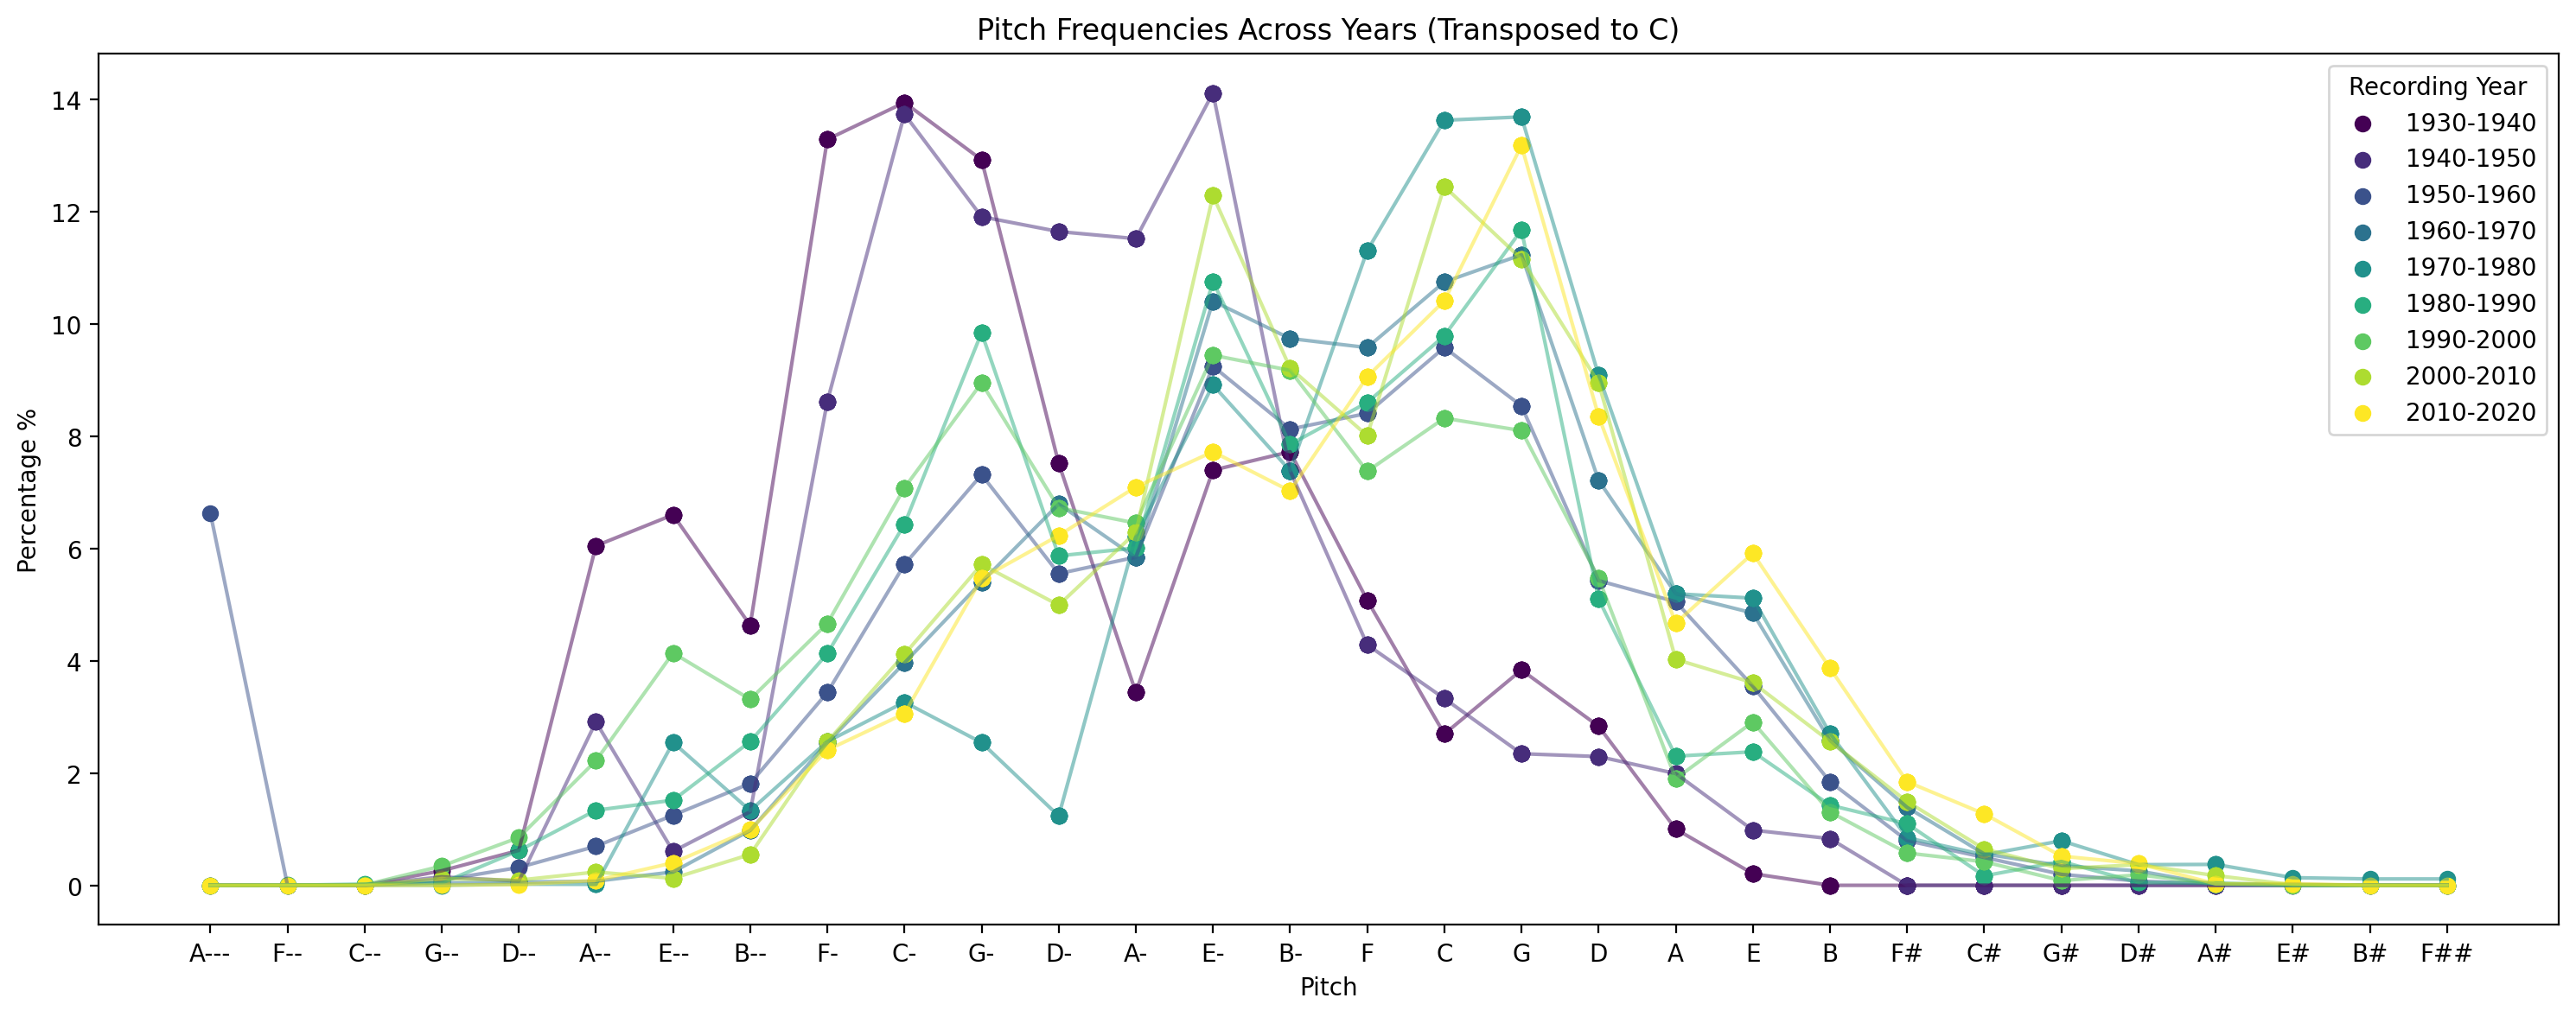

In [74]:
fig, ax = plt.subplots(figsize=(15, 6))  # One figure and one axis

colors = plt.cm.get_cmap('viridis', len(keys))  # Distinct colors

for i, key in enumerate(keys):
    if isinstance(key, tuple):
        label = " – ".join(str(k) for k in key)
    else:
        label = str(key)

    # Get the pitch profile data
    pitch_data = data_year[key]
    tpc = pd.DataFrame({
        'transposed note': pitch_data['transposed note'],
        'transposed tpc': pitch_data['transposed tpc'],
        'duration': pitch_data['duration']
    })

    pitch_counts = tpc.groupby(['transposed note', 'transposed tpc'])['duration'].sum().reset_index(name='weighted_count')
    count = pitch_counts.sort_values('transposed tpc')
    total = count['weighted_count'].sum()
    count['percentage'] = (count['weighted_count'] / total)*100

    merged_df = pd.merge(
        baseline_df_tranposed[['transposed note']],
        count[['transposed note', 'percentage']],
        on='transposed note',
        how='left'
    )
    
    # Step 3: fill NaNs with 0 where artist didn't have that interval
    merged_df['percentage'] = merged_df['percentage'].fillna(0)

    # Plot line for this artist
    ax.plot(merged_df['transposed note'], merged_df['percentage'], color=colors(i), alpha=0.5)
    ax.scatter(merged_df['transposed note'], merged_df['percentage'], label=label, color=colors(i))

# Axis labels and title
ax.set_xlabel('Pitch')
ax.set_ylabel('Percentage %')
ax.set_title(f'Pitch Frequencies Across Years (Transposed to C)')
ax.legend(title='Recording Year')

plt.tight_layout()
plt.savefig(f"../Results/0623_YearTransposedPitchOverlay")
plt.show()